In [10]:
from sklearn import datasets
iris = datasets.load_iris()

In [3]:
pip install fuzzy-c-means

  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster

In [14]:
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,adjusted_mutual_info_score

In [16]:
# C-means
from fcmeans import FCM

In [18]:
X = iris.data

In [20]:
model = KMeans(n_clusters = 3, random_state = 42, n_init = 30)
model

KMeans(n_clusters=3, n_init=30, random_state=42)

In [22]:
model.fit(X)

C:\Users\User\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, n_init=30, random_state=42)

In [23]:
model.cluster_centers_

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [26]:
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [28]:
silhouette_score(X,model.labels_)

0.5528190123564093

In [30]:
y  = iris.target

In [32]:
adjusted_mutual_info_score(y,model.labels_)

0.7551191675800484

In [34]:
#C_means
model_C = FCM (n_clusters = 3)
model_C.fit(X)

In [36]:
model_C.centers

array([[5.00396596, 3.41408891, 1.48281545, 0.25354628],
       [6.77500995, 3.0523819 , 5.64678019, 2.05354604],
       [5.88893131, 2.76106898, 4.3639501 , 1.39731425]])

In [38]:
fcm_labels = model_C.predict(X)

In [40]:
silhouette_score(X,fcm_labels)

0.5495175126471619

In [42]:
adjusted_mutual_info_score(y,fcm_labels)

0.7464681806208395

In [44]:
dbscan = DBSCAN (eps = 0.6, min_samples = 10).fit(X)
dbscan

DBSCAN(eps=0.6, min_samples=10)

In [46]:
silhouette_score(X,dbscan.labels_ )

0.542120393671645

In [48]:
adjusted_mutual_info_score(y,dbscan.labels_)

0.6162312414524299

# Кластерный анализ

In [64]:
df = pd.read_csv('beverage_r.csv', sep=';', index_col = 'numb.obs')
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [66]:
df.shape

(34, 8)

In [90]:
link = linkage(df,'average','euclidean')

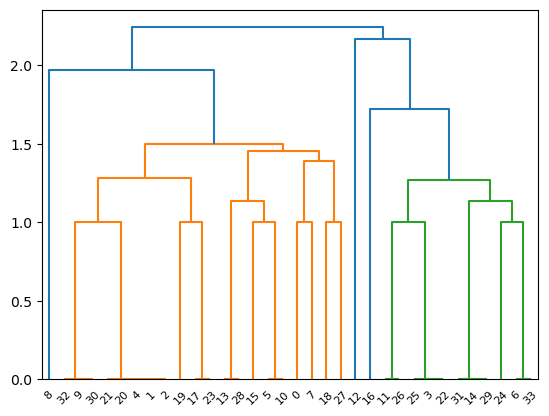

In [92]:
dendrogram(link);

In [94]:
df['cluster'] = fcluster(link,2,criterion = 'maxclust')
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,1
2,1,0,0,0,1,0,0,0,1
3,1,0,0,0,1,0,0,0,1
4,0,1,0,1,0,0,1,0,2
5,1,0,0,0,1,0,0,0,1


In [96]:
df.groupby('cluster').size()

cluster
1    21
2    13
dtype: int64

In [98]:
df = pd.read_csv('beverage_r.csv', sep=';', index_col = 'numb.obs')

In [100]:
model = KMeans(n_clusters = 2, random_state = 42, n_init = 30).fit(df)
model

C:\Users\User\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2, n_init=30, random_state=42)

In [102]:
silhouette_score(df,model.labels_ )

0.4040663842469348